In [9]:
import xtrack as xt
import xpart as xp
import xfields as xf 
import xobjects as xo
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import json

In [ ]:
line = xt.Line.from_json('/home/mwatson/Documents/laughing-octo-bassoon/Polarization and tracking/D1 C1/D1_C1_corrections.json')
line.element_dict['RFCav'].voltage = 16e6     # Set to 12.65 MV
line.element_dict['RFCav_1'].voltage = 16e6
# Print out the expressions controlling the voltage
print(line.element_dict['RFCav'])

line.configure_radiation('mean')


line.discard_tracker()
line.build_tracker()


tw = line.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                   spin=True, polarization=True)

fRev = 1./(tw.T_rev0)
fRF  = fRev*round(4.e8/fRev) 

line.element_dict['RFCav'].voltage = 16e6     # Set to 12.65 MV
line.element_dict['RFCav_1'].voltage = 16e6

print(tw.cols)
np.random.seed(0)
particles = xp.generate_matched_gaussian_bunch(
    line=line,
    nemitt_x=tw.eq_nemitt_x,
    nemitt_y=tw.eq_nemitt_y,
    sigma_z=np.sqrt(tw.eq_gemitt_zeta * tw.bets0),
    num_particles=300)
# Add stable phase
particles.zeta += tw.zeta[0]
particles.delta += tw.delta[0]

# Initialize spin of all particles along n0
particles.spin_x = tw.spin_x[0]
particles.spin_y = tw.spin_y[0]
particles.spin_z = tw.spin_z[0]

# Simulate bunch evolution with stochastic photon emission
line.configure_spin('auto')
line.configure_radiation(model='quantum')

# Enable parallelization
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))

# Track
num_turns=10000
line.track(particles, num_turns=num_turns, turn_by_turn_monitor=True,
           with_progress=10)
mon = line.record_last_track


# Fit depolarization time
mask_alive = mon.state > 0
pol_x = mon.spin_x.sum(axis=0)/mask_alive.sum(axis=0)
pol_y = mon.spin_y.sum(axis=0)/mask_alive.sum(axis=0)
pol_z = mon.spin_z.sum(axis=0)/mask_alive.sum(axis=0)
pol = np.sqrt(pol_x**2 + pol_y**2 + pol_z**2)

i_start = 3 # Skip a few turns (small initial mismatch)
pol_to_fit = pol[i_start:]/pol[i_start]

turns = np.arange(len(pol_to_fit))
slope, intercept, r_value, p_value, std_err = linregress(turns, pol_to_fit)
# Calculate depolarization time
t_dep_turns = -1 / slope


Loading line from dict:   0%|          | 0/6439 [00:00<?, ?it/s]

Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
Cavity(length=1.5, voltage=1.6e+07, frequency=4e+08, lag=175, harmonic=0, lag_taper=0, absolute_time=0, num_kicks=0, model='adaptive', integrator='adaptive', shift_x=0, shift_y=0, shift_s=0, rot_s_rad=0, rot_x_rad=0, rot_y_rad=0, rot_s_rad_no_frame=0, rot_shift_anchor=0)
ColView: name s x px y py zeta delta ptau W_matrix kin_px kin_py kin_ps kin_xprime kin_yprime env_name spin_x spin_y spin_z betx bety alfx alfy gamx gamy dx dpx dy dpy dx_zeta dpx_zeta dy_zeta dpy_zeta betx1 bety1 betx2 bety2 alfx1 alfy1 alfx2 alfy2 gamx1 gamy1 gamx2 gamy2 mux muy muzeta nux nuy nuzeta phix phiy phizeta c_minus_re c_minus_im c_r1 c_r2 c_phi1 c_phi2 dmux dmuy dzeta bx_chrom by_chrom ax_chrom ay_chrom wx_chrom wy_chrom ddx ddpx ddy ddpy angle_rad rot_s_rad length radiation_flag k0l k1l k2l k3l k4l k5l k0sl k1sl k2sl k3sl k4sl k5sl angle_rad rot_s_rad hkick vkick ks length _angle_force_b

ValueError: No longitudinal focusing found in the line. Cannot generate matched longitudinal coordinates.

0.08930045603989417


Text(0.5, 0.04, 'Calculated Equilibrium Polarization ($P_{eq}$): 0.089')

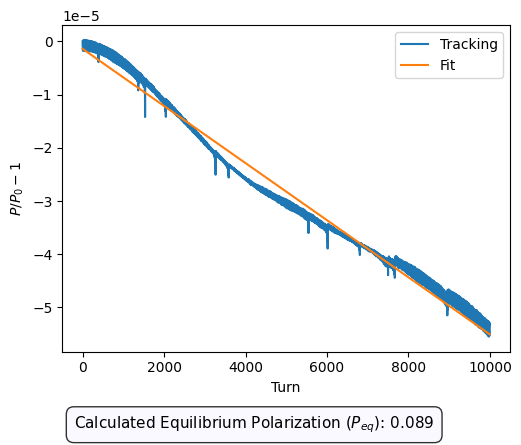

In [ ]:

# Plot polarization decay and fit
plt.figure()
plt.plot(pol_to_fit-1, label='Tracking')
plt.plot(turns, intercept*np.exp(-turns/t_dep_turns) - 1, label='Fit')
plt.ylabel(r'$P/P_0 - 1$')
plt.xlabel('Turn')
plt.subplots_adjust(left=.2)
plt.legend()

# Compute equilibrium polarization
p_inf = tw['spin_polarization_inf_no_depol']
t_pol_turns = tw['spin_t_pol_component_s']/tw.T_rev0

p_eq = p_inf * 1 / (1 + t_pol_turns/t_dep_turns)
print(p_eq)
plt.subplots_adjust(bottom=0.2)
plt.figtext(0.5, 0.04, f"Calculated Equilibrium Polarization ($P_{{eq}}$): {p_eq:.3f}", 
            ha="center", fontsize=11, 
            bbox=dict(facecolor='ghostwhite', alpha=0.8, boxstyle='round,pad=0.5'))
